# DICOM files reading and visualization tutorial
In this tutorial you will familiarize yourself with DICOM, the most common format used for transferring and storing medical images.
Your task will be to read a couple of MR sequencues, and visualize them correctly

## Imports
You will read dicom files using the dcmread module from pydicom
numpy to handle data arrays
glob to parse the data files
matplotlib.pyplot to visualize

In [1]:
import glob
import pydicom.errors

import numpy as np
import matplotlib.pyplot as plt

from pydicom import dcmread

## Read all the files in a directory

Dicom stores (generally) every "sequence" in a directory, with one file per slice. You need to iterate over all of them to reconstruct a volume.
dcmread returns a structure containing multiple information concerning each file, including all the header.

1. Find all the files in DICOM subdirectory and read them using dcmread(filename), store them in a list. You can use glob
2. Can you read all of them? If not why? Hint: if a non-dicom file is present dcmread raises this error: pydicom.errors.InvalidDicomError
3. Parse trough the header of the first slice. Find the patient name, birthdate, weight

In [2]:
files = glob.glob("DICOM/*")

print("Amount of files: ", len(files))

Amount of files:  314


In [3]:
read_files = []
non_read_files = []

for file in files:
    try:
        read_files.append(dcmread(file))
    except pydicom.errors.InvalidDicomError as e:
        print(" File ", file, "not added.\n", e)


 File  DICOM/desktop.ini not added.
 File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.


In [4]:
# Find patient's name, birthdate and weight
first_file = dcmread(files[0])

print("Patient's Name: ", first_file.get("PatientName"))
print("Patient's Weight: ", first_file.get("PatientWeight"))
print("Patient's Birthday: ", first_file.get("PatientBirthday", "-"))

Patient's Name:  Anon^1
Patient's Weight:  80.0
Patient's Birthday:  -


## Order the slices and build a volume

1. Each dicom file has a field called "SliceLocation". As you cannot trust the idea that files are in the correct order to be stacked, you need to stack them after sorting them using the SliceLocation.

2. Declare an empty numpy array to be filled. Each file is a 2D matrix, with dimensions written in the pixel_array.shape property. The n° of slices is the numer of files.

3. Fill the volume by looping over each slice, and storing this 2D matrix in the 3D array (.pixel_array property)


In [5]:
sorted_slices = sorted(read_files, key=lambda f: f.SliceLocation)

img_shape = list(first_file.pixel_array.shape)
img_shape.append(len(sorted_slices))
img3d = np.zeros(img_shape)

for i, s in enumerate(sorted_slices):
    img2d = s.pixel_array
    img3d[:, :, i] = img2d * s.RescaleSlope + s.RescaleIntercept
    # The Hounsfield Unit formula: pixel * RescaleSlope + RescaleIntercept is a DICOM standard linear transformation
    # that maps raw scanner integers to a physical scale where:
    #   -1000 = air
    #   0 = water
    #   400–1000 = bone

## Display slices of the volume

Display three different planes of the volume

**Take a look at the results**

Do all three images look good? Is the default colormap good for MR? Are the images flipped correctly?

Try again a better display, taking into account that images have different pixel sizes over the three axes. Specifically, the pixel of the 2D matrix have sized described in the property PixelSpacing , while the slices are spaced by SliceThickness

In matplotlib you can set the aspect ratio by doing 

        a1 = plt.subplot(2,2,1)
        plt.imshow(imm)
        a1.set_aspect(pixelSizeY/pixelSizeX)
Note that you need to put the X axis in the numerator and the Y in the denominator, as matplotlib transposes the axes!!

Note that coordinates, flips, orientation etc... are all described in dicom headers, but this is not a core topic of the course.

In [6]:
img3d.shape

(512, 512, 313)

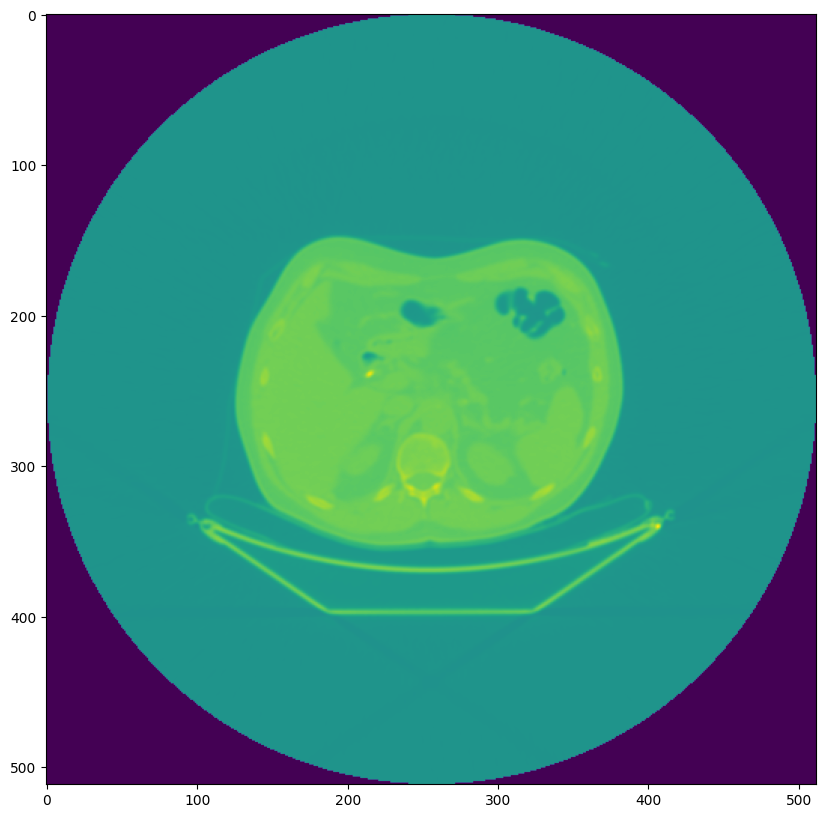

In [7]:
plt.figure(figsize=(10, 10))
_ = plt.imshow(img3d[:, :, img_shape[-1] // 2])  # ,cmap='gray',vmin=-1024,vmax=0)

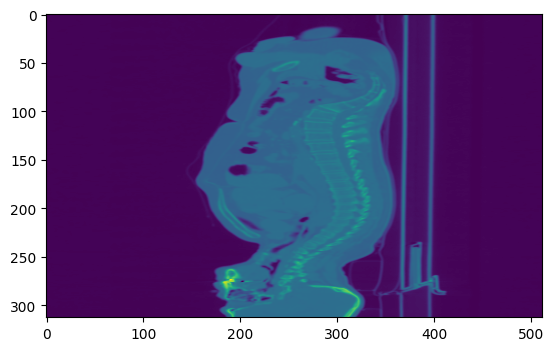

In [8]:
_ = plt.imshow(img3d[:, img_shape[1] // 2, :].T)

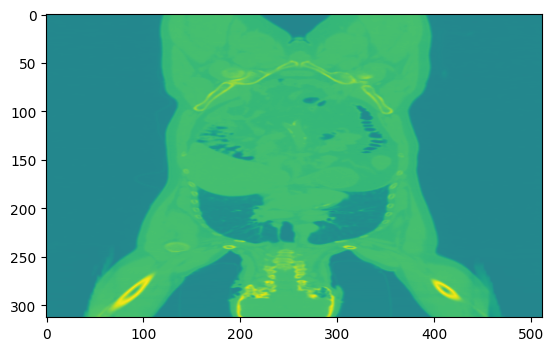

In [9]:
_ = plt.imshow(img3d[img_shape[0] // 2, :, :].T)

In [10]:
sorted_slices[0].SliceThickness

'3.75'

In [11]:
sorted_slices[0].PixelSpacing

[1.367188, 1.367188]

In [12]:
ps = sorted_slices[0].PixelSpacing
ss = sorted_slices[0].SliceThickness
ax_aspect = ps[0] / ps[1]
sag_aspect = ps[1] / ss
cor_aspect = ss / ps[0]

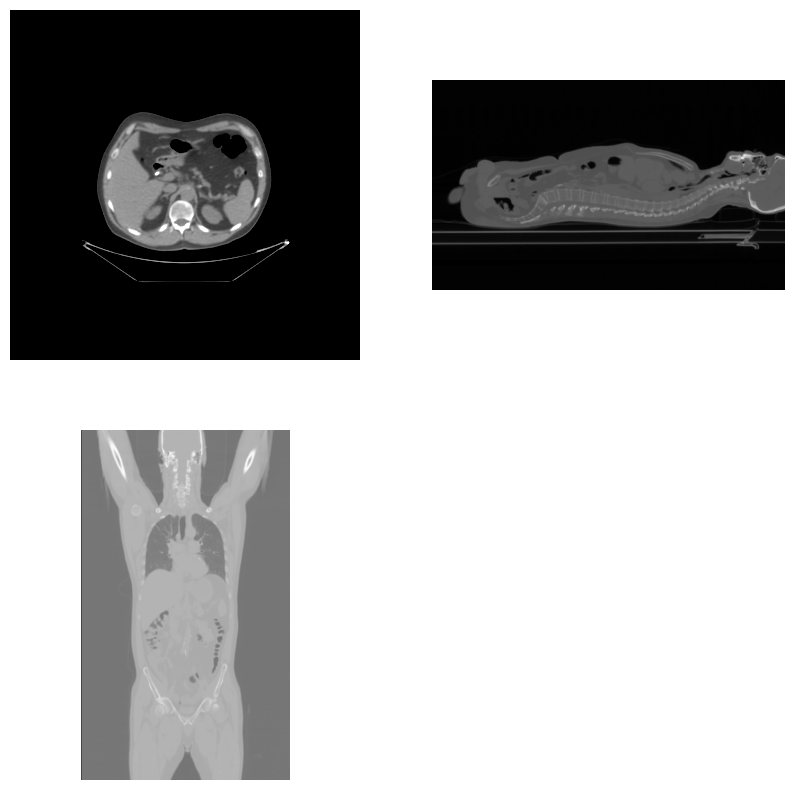

In [13]:
plt.figure(figsize=(10, 10))
a1 = plt.subplot(2, 2, 1)
plt.imshow(img3d[:, :, img_shape[2] // 2], cmap="gray", vmin=-220, vmax=240)
a1.set_aspect(ax_aspect)
# plt.colorbar()

plt.axis("off")
a2 = plt.subplot(2, 2, 2)
plt.imshow(img3d[:, img_shape[1] // 2, :], cmap="gray")
a2.set_aspect(sag_aspect)

plt.axis("off")
a3 = plt.subplot(2, 2, 3)
plt.imshow(np.flip(img3d[img_shape[0] // 2, :, :].T, axis=0), cmap="gray")
a3.set_aspect(cor_aspect)

plt.axis("off")
plt.show()

# Multiple possible windows

(np.float64(-0.5), np.float64(299.5), np.float64(249.5), np.float64(-0.5))

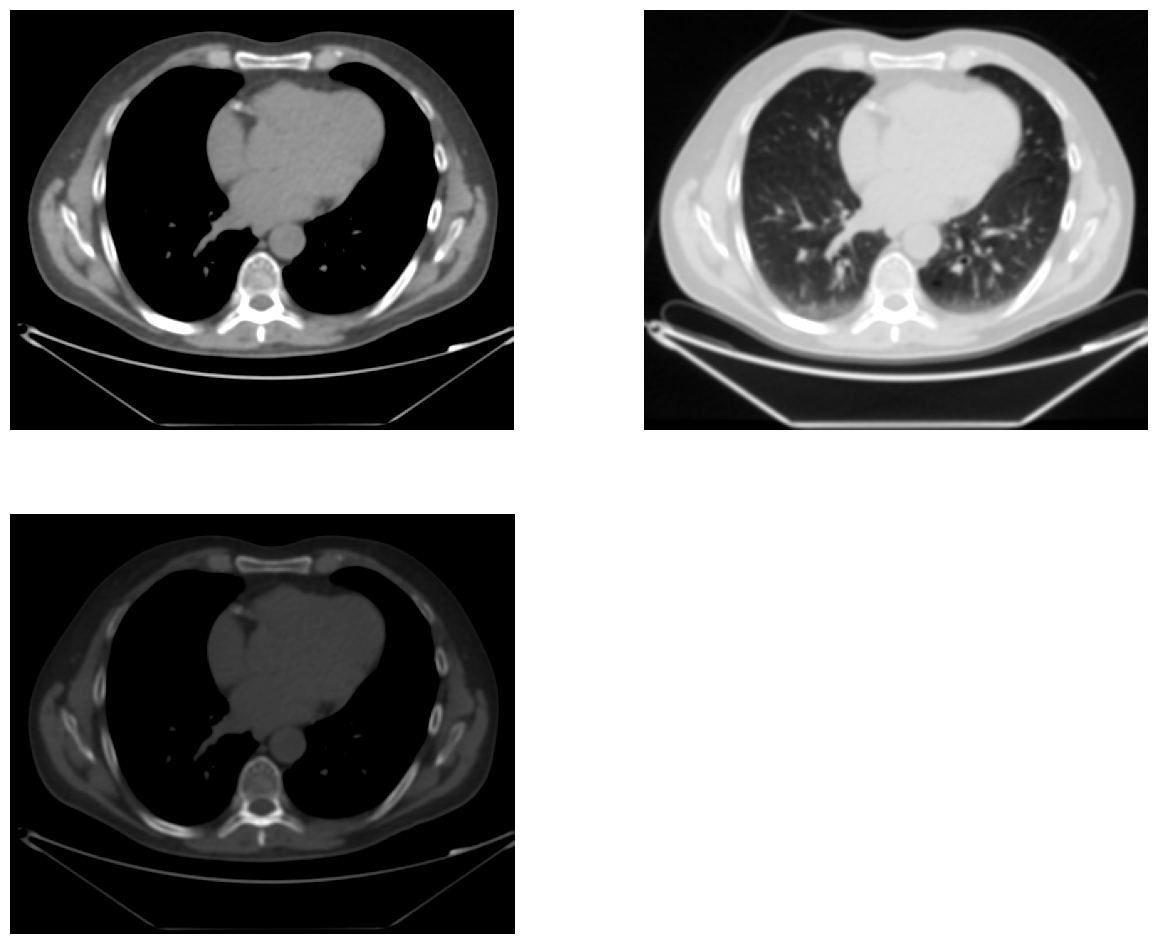

In [14]:
plt.figure(figsize=(15, 12))
plt.subplot(221)
plt.imshow(img3d[150:400, 100:400, -120], cmap="gray", vmin=-220, vmax=240)
plt.axis("off")
plt.subplot(222)
plt.imshow(img3d[150:400, 100:400, -120], cmap="gray", vmin=-1024, vmax=240)
plt.axis("off")
plt.subplot(223)
plt.imshow(img3d[150:400, 100:400, -120], cmap="gray", vmin=-200, vmax=800)
plt.axis("off")

In [15]:
imgRedS = img3d[::3, ::3, ::3]

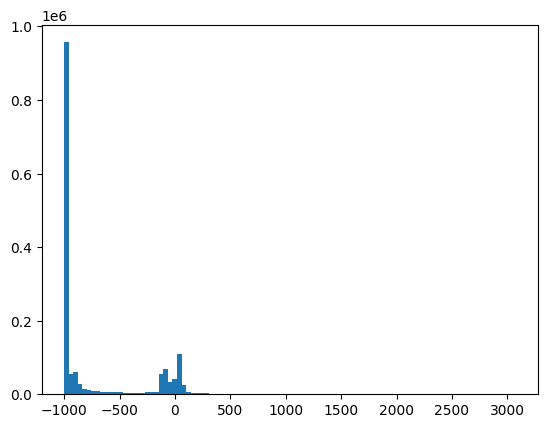

In [16]:
_ = plt.hist(imgRedS[imgRedS > -1000].flat, 100)